In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
GSE63060_path = "/content/drive/MyDrive/Colab Notebooks/Personal/brain_disease_prediction/GEO/Alzheimer/blood tissue/GSE63060_expression.csv"
GSE63061_path = "/content/drive/MyDrive/Colab Notebooks/Personal/brain_disease_prediction/GEO/Alzheimer/blood tissue/GSE63061_expression.csv"

In [3]:
GSE63060 = pd.read_csv(GSE63060_path)
GSE63061 = pd.read_csv(GSE63061_path)

In [4]:
GSE63060.rename(columns={'Unnamed: 0':'patient_id'}, inplace=True)
GSE63061.rename(columns={'Unnamed: 0':'patient_id'}, inplace=True)

In [5]:
GSE63060.set_index('patient_id', inplace=True)
GSE63061.set_index('patient_id', inplace=True)

In [6]:
GSE63061

,1-Dec,1-Mar,2-Mar,3-Mar,5-Mar,6-Mar,7-Mar,8-Mar,9-Mar,A1BG,...,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,dJ222E13.2,dJ341D10.1,gm127,psiTPTE22,status
patient_id,,,,,,,,,,,,,,,,,,,,,
GSM1539409,6.046115,6.268807,7.793198,6.247908,6.217792,7.715288,7.880070,6.898175,6.097052,6.363700,...,6.024313,8.223230,9.639303,7.686363,6.312076,6.051220,6.236891,6.114106,6.017242,MCI
GSM1539410,6.068269,6.332623,7.822572,6.253956,6.146553,7.815891,7.950036,6.631771,6.110334,6.038703,...,6.044935,8.423643,10.255327,7.729719,6.234654,6.083923,6.398889,6.144168,6.022783,MCI
GSM1539411,6.049894,6.451657,7.821084,6.299298,6.231308,8.063262,8.578855,7.258313,6.028404,6.149995,...,6.050358,8.126528,9.643614,7.526946,6.441426,6.059549,6.322824,6.043692,6.096135,MCI
GSM1539412,6.022627,6.204796,8.183803,6.242987,6.073113,8.299693,7.528975,7.545952,6.125845,6.364765,...,6.024002,8.443437,9.966027,7.485560,6.167969,6.079597,6.177225,6.192038,6.032421,MCI
GSM1539413,6.024455,6.410122,8.448412,6.185270,6.168115,8.330396,8.040028,7.083462,6.071435,6.154938,...,6.014700,8.657116,9.640727,7.288133,6.422155,6.029469,6.324525,6.072912,6.056553,MCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM1539792,6.050681,6.393572,7.546375,6.252932,6.226305,8.170299,7.806016,6.963304,6.062263,6.139319,...,6.086113,8.659101,10.350903,7.713113,6.271670,6.104885,6.656707,6.005648,6.031678,MCI
GSM1539793,6.110553,6.376821,8.007593,6.263650,6.138989,8.021647,7.953865,6.968087,5.999827,6.192208,...,6.022127,8.149314,9.762687,7.363716,6.354014,6.010161,6.407741,6.259958,6.103267,MCI
GSM1539794,6.017178,6.375036,7.813062,6.132921,6.176351,8.116965,8.569122,6.976714,6.016029,6.089414,...,6.053900,8.218770,9.624390,7.468304,6.346038,6.088197,6.388553,6.107970,6.044537,AD


In [7]:
print(len(GSE63060.columns))
print(len(GSE63061.columns))

21697
22337


In [8]:
common_genes = GSE63060.columns.intersection(GSE63061.columns)

print("Common genes:", len(common_genes))

Common genes: 17154


In [9]:
GSE63061 = GSE63061[
    GSE63061["status"].isin(["AD", "MCI", "CTL"])
]

# Optional check
print(GSE63061["status"].value_counts())
print(GSE63061.shape)

status
AD     139
CTL    134
MCI    109
Name: count, dtype: int64
(382, 22337)


In [10]:
GSE63060_common = GSE63060[common_genes]
GSE63061_common = GSE63061[common_genes]

In [11]:
merged_df = pd.concat(
    [GSE63060_common, GSE63061_common],
    axis=0
)

print(merged_df.shape)

(711, 17154)


In [12]:
merged_df

,A1BG,A1CF,A26C3,A2BP1,A4GALT,A4GNT,AAA1,AAAS,AACS,AACSL,...,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,dJ222E13.2,dJ341D10.1,gm127,psiTPTE22,status
patient_id,,,,,,,,,,,,,,,,,,,,,
GSM1539080,7.600951,7.497117,7.476685,7.463816,7.476840,7.499282,7.638083,7.585404,8.148446,7.594694,...,7.462498,10.618034,11.736463,8.561519,7.525411,7.738314,7.786112,7.466882,7.499674,MCI
GSM1539081,7.672496,7.463011,7.651896,7.570863,7.445267,7.656974,7.460855,7.612667,8.315475,7.492516,...,7.472825,11.289126,11.930612,8.697649,7.666053,7.602051,7.707824,7.498424,7.648523,MCI
GSM1539082,7.538046,7.475873,7.461754,7.484247,7.314818,7.530972,7.445645,7.756228,7.912023,7.630822,...,7.435084,11.068854,11.626505,8.889266,7.771253,7.775860,7.764043,7.415565,7.505945,MCI
GSM1539083,7.577860,7.503082,7.488248,7.508958,7.486045,7.542443,7.525906,7.984069,8.064728,7.487097,...,7.377990,10.527572,11.954639,8.665815,7.696854,8.114773,7.459060,7.608580,7.534026,MCI
GSM1539084,7.678150,7.417203,7.481259,7.443698,7.428502,7.436986,7.411262,7.761655,7.977451,7.517720,...,7.453386,10.833655,11.895018,8.785981,7.647086,7.705824,7.563035,7.484933,7.564126,MCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM1539792,6.139319,6.020684,6.065013,6.040905,6.018924,6.014391,6.112325,6.159050,6.191944,6.325955,...,6.086113,8.659101,10.350903,7.713113,6.271670,6.104885,6.656707,6.005648,6.031678,MCI
GSM1539793,6.192208,6.037401,6.073189,6.018387,6.011448,6.220108,6.050225,6.081145,6.123798,6.240833,...,6.022127,8.149314,9.762687,7.363716,6.354014,6.010161,6.407741,6.259958,6.103267,MCI
GSM1539794,6.089414,6.030420,6.073272,6.032869,6.009287,6.116415,6.056126,6.076175,6.255484,6.174056,...,6.053900,8.218770,9.624390,7.468304,6.346038,6.088197,6.388553,6.107970,6.044537,AD


In [39]:
merged_df["status"].value_counts()

,count
status,
AD,284
CTL,238
MCI,189


### LOG NORMALIZATION

In [13]:
X = merged_df.drop(columns=["status"])
y = merged_df["status"]


X_log = np.log2(X + 1)

### VARIANCE FILTERING

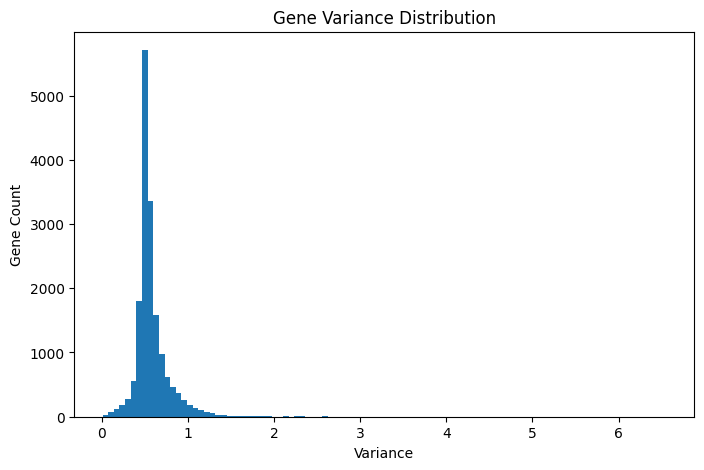

In [14]:
gene_variance = merged_df.drop(columns=["status"]).var()

plt.figure(figsize=(8,5))
plt.hist(gene_variance, bins=100)
plt.title("Gene Variance Distribution")
plt.xlabel("Variance")
plt.ylabel("Gene Count")
plt.show()

In [15]:
variance = X_log.var()

threshold = variance.quantile(0.75)

selected_genes = variance[variance > threshold].index

X_filtered = X_log[selected_genes]

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### ANOVA FEATURE SELECTION

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

anova_selector = SelectKBest(score_func=f_classif, k=1000)

X_anova = anova_selector.fit_transform(
    X_train,
    y_train
)

In [19]:
X_anova.shape

(568, 1000)

### MUTUAL INFORMATION

In [20]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train
)

mi_df = pd.DataFrame({
    "Gene": X_filtered.columns,
    "MI": mi_scores
}).sort_values("MI", ascending=False)

In [21]:
top_genes = mi_df["Gene"].head(1000)

X_train_mi = X_train[top_genes]
X_test_mi = X_test[top_genes]

In [22]:
mi_df

,Gene,MI
4045,UQCRB,0.145165
802,COX17,0.137266
805,COX6C,0.133869
2086,LOC646200,0.128241
604,CCDC53,0.126276
...,...,...
2942,PIGV,0.000000
2912,PGAM5,0.000000
2914,PGGT1B,0.000000
2916,PGLYRP1,0.000000


### PCA

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train)

In [24]:
X_test_pca = pca.transform(X_test)

### SVD

In [25]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50)

X_train_svd = svd.fit_transform(X_train)

X_test_svd = svd.transform(X_test)

### DEEP AUTOENCODER

In [26]:
from tensorflow.keras import layers, Model
from tensorflow import keras
import tensorflow as tf

input_dim = X_train.shape[1]

inputs = layers.Input(shape=(input_dim,))

x = layers.Dense(2048, activation='relu')(inputs)
x = layers.Dropout(0.3)(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)

latent = layers.Dense(32, activation='relu', name="latent")(x)

x = layers.Dense(128, activation='relu')(latent)
x = layers.Dense(512, activation='relu')(x)

outputs = layers.Dense(input_dim, activation='linear')(x)

autoencoder = Model(inputs, outputs)
encoder = Model(inputs, latent)

In [27]:
autoencoder.compile(optimizer='adam', loss='mse')

model = autoencoder.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - loss: 2.9982 - val_loss: 0.5099
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - loss: 0.2208 - val_loss: 0.0943
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - loss: 0.0701 - val_loss: 0.0119
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 0.0494 - val_loss: 0.0665
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - loss: 0.0377 - val_loss: 0.2254
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - loss: 0.0384 - val_loss: 0.0534
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - loss: 0.0407 - val_loss: 0.0541
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - loss: 0.0288 - val_loss: 0.0306
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - loss: 0.0436 - val_loss: 0.0614
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 241ms/step - loss: 0.0352 - val_loss: 0.2407
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - loss: 0.0388 - val_loss: 0.0434
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step

In [28]:
X_train_ae = encoder.predict(X_train)
X_test_ae = encoder.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [29]:
len(X_test_ae)

143

# 1. MLP Model


In [37]:
def build_model(input_dim):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(len(np.unique(y)), activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

def model_report(name, y_test, y_pred):
    print("\n" + "="*60)
    print(f"📊 MODEL REPORT: {name}")
    print("="*60)

    print("\n🔹 Accuracy:")
    print(accuracy_score(y_test, y_pred))

    print("\n🔹 Classification Report:")
    print(classification_report(y_test, y_pred))

    print("\n🔹 Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [52]:
model_pca = build_model(X_train_pca.shape[1])

history = model_pca.fit(
    X_train_pca,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.3502 - loss: 1.3242 - val_accuracy: 0.2807 - val_loss: 1.1408
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3855 - loss: 1.1421 - val_accuracy: 0.3246 - val_loss: 1.1076
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3656 - loss: 1.1456 - val_accuracy: 0.3596 - val_loss: 1.1058
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3546 - loss: 1.1169 - val_accuracy: 0.4123 - val_loss: 1.0878
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3899 - loss: 1.1155 - val_accuracy: 0.4123 - val_loss: 1.0870
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3965 - loss: 1.1125 - val_accuracy: 0.4123 - val_loss: 1.0922
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4141 - loss: 1.1002 - val_accuracy: 0.4298 - val_loss: 1.0900
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4559 - loss: 1.0981 - val_accuracy: 0.

In [53]:
y_pred_pca = np.argmax(model_pca.predict(X_test_pca), axis=1)


model_report("PCA + MLP", y_test, y_pred_pca)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

📊 MODEL REPORT: PCA + MLP

🔹 Accuracy:
0.5244755244755245

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.60      0.62        57
           1       0.51      0.54      0.53        48
           2       0.38      0.39      0.38        38

    accuracy                           0.52       143
   macro avg       0.51      0.51      0.51       143
weighted avg       0.53      0.52      0.53       143


🔹 Confusion Matrix:
[[34 11 12]
 [ 9 26 13]
 [ 9 14 15]]


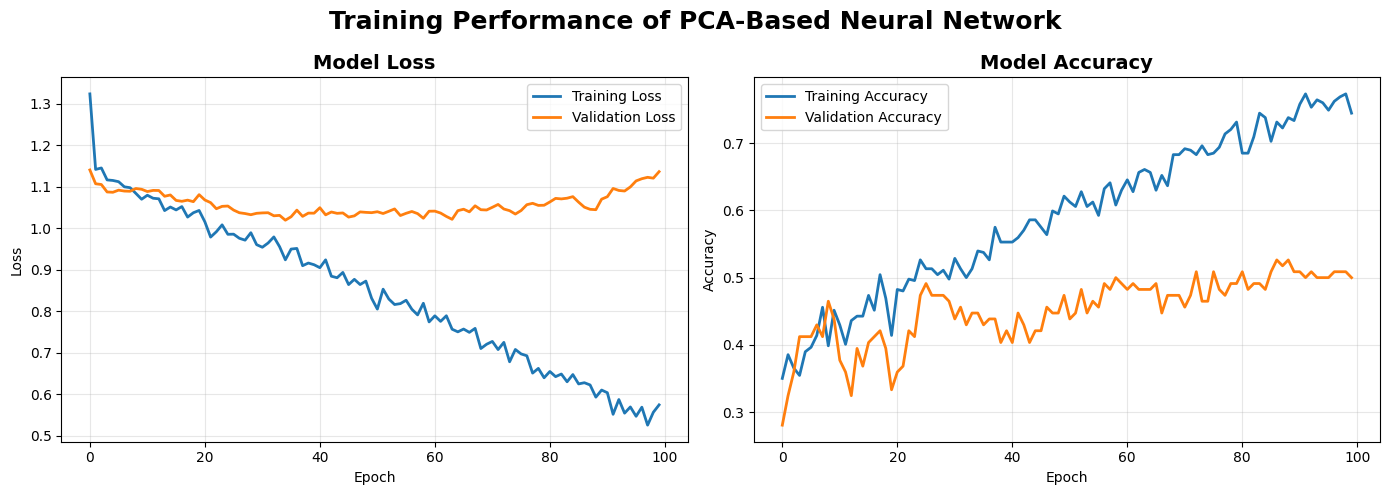

In [54]:
# @title
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------------
# Loss
# ----------------------------
axes[0].plot(
    history.history['loss'],
    linewidth=2,
    label='Training Loss'
)

axes[0].plot(
    history.history['val_loss'],
    linewidth=2,
    label='Validation Loss'
)

axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

# ----------------------------
# Accuracy
# ----------------------------
axes[1].plot(
    history.history['accuracy'],
    linewidth=2,
    label='Training Accuracy'
)

axes[1].plot(
    history.history['val_accuracy'],
    linewidth=2,
    label='Validation Accuracy'
)

axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)
axes[1].legend()

# ----------------------------
# Overall Figure
# ----------------------------
fig.suptitle(
    'Training Performance of PCA-Based Neural Network',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [56]:
y_proba_pca = model_pca.predict(X_test_pca)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


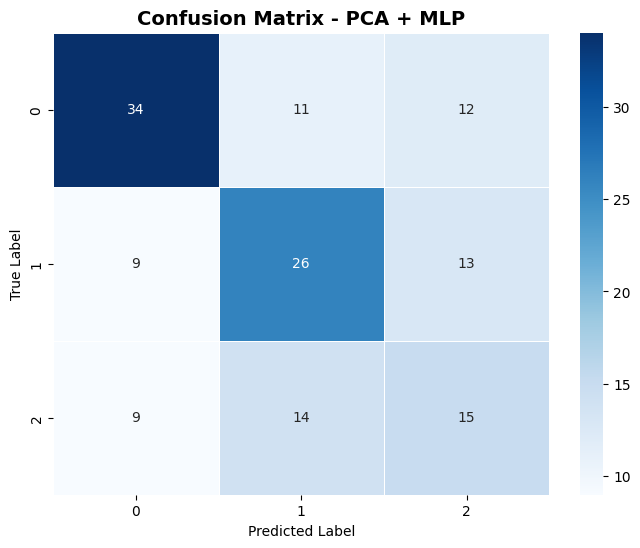

In [61]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_pca)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar=True
)

plt.title("Confusion Matrix - PCA + MLP", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [58]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_pca[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

/tmp/ipykernel_2629/4249872951.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", n_classes)


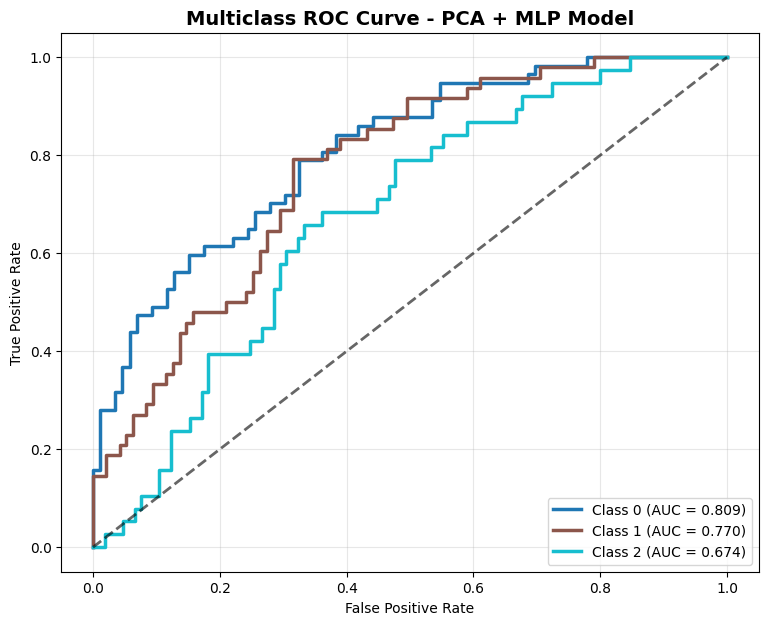

In [59]:
plt.figure(figsize=(9, 7))

colors = plt.cm.get_cmap("tab10", n_classes)

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=2.5,
        color=colors(i),
        label=f"Class {classes[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Diagonal line
plt.plot([0, 1], [0, 1], "k--", lw=2, alpha=0.6)

plt.title("Multiclass ROC Curve - PCA + MLP Model", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")

plt.show()

In [43]:
model_ae = build_model(X_train_ae.shape[1])

model_ae.fit(
    X_train_ae,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.2952 - loss: 3.9508 - val_accuracy: 0.2807 - val_loss: 3.0680
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3546 - loss: 2.2198 - val_accuracy: 0.2807 - val_loss: 1.2576
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3304 - loss: 1.6823 - val_accuracy: 0.4123 - val_loss: 1.1104
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3216 - loss: 1.5312 - val_accuracy: 0.4123 - val_loss: 1.0973
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3502 - loss: 1.3957 - val_accuracy: 0.2807 - val_loss: 1.1309
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3480 - loss: 1.3176 - val_accuracy: 0.2807 - val_loss: 1.1821
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3722 - loss: 1.2175 - val_accuracy: 0.2807 - val_loss: 1.1690
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.3480 - loss: 1.2562 - val_accuracy: 0.

In [44]:
y_pred_ae = np.argmax(model_ae.predict(X_test_ae), axis=1)


model_report("AE + MLP", y_test, y_pred_ae)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

📊 MODEL REPORT: AE + MLP

🔹 Accuracy:
0.3986013986013986

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.40      1.00      0.57        57
           1       0.00      0.00      0.00        48
           2       0.00      0.00      0.00        38

    accuracy                           0.40       143
   macro avg       0.13      0.33      0.19       143
weighted avg       0.16      0.40      0.23       143


🔹 Confusion Matrix:
[[57  0  0]
 [48  0  0]
 [38  0  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
model_svd = build_model(X_train_svd.shape[1])

model_svd.fit(
    X_train_svd,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3811 - loss: 7.4852 - val_accuracy: 0.3070 - val_loss: 2.9222
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3899 - loss: 5.5339 - val_accuracy: 0.3070 - val_loss: 1.3090
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3458 - loss: 4.1195 - val_accuracy: 0.3158 - val_loss: 1.1904
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3216 - loss: 3.3898 - val_accuracy: 0.4123 - val_loss: 1.1052
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3150 - loss: 2.7158 - val_accuracy: 0.4123 - val_loss: 1.0907
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3833 - loss: 2.2181 - val_accuracy: 0.4123 - val_loss: 1.1138
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3700 - loss: 2.0427 - val_accuracy: 0.4123 - val_loss: 1.1089
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3260 - loss: 2.0235 - val_accuracy: 0.

In [49]:
y_pred_svd = np.argmax(model_svd.predict(X_test_svd), axis=1)


model_report("PCA + MLP", y_test, y_pred_svd)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

📊 MODEL REPORT: PCA + MLP

🔹 Accuracy:
0.3986013986013986

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.40      1.00      0.57        57
           1       0.00      0.00      0.00        48
           2       0.00      0.00      0.00        38

    accuracy                           0.40       143
   macro avg       0.13      0.33      0.19       143
weighted avg       0.16      0.40      0.23       143


🔹 Confusion Matrix:
[[57  0  0]
 [48  0  0]
 [38  0  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
model_mi = build_model(X_train_mi.shape[1])

model_mi.fit(
    X_train_mi,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.3877 - loss: 2.1864 - val_accuracy: 0.4123 - val_loss: 1.0893
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3502 - loss: 1.1970 - val_accuracy: 0.3421 - val_loss: 1.0989
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3304 - loss: 1.1013 - val_accuracy: 0.4123 - val_loss: 1.0964
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3965 - loss: 1.0966 - val_accuracy: 0.4123 - val_loss: 1.0954
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3965 - loss: 1.0946 - val_accuracy: 0.4123 - val_loss: 1.0942
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3965 - loss: 1.0930 - val_accuracy: 0.4123 - val_loss: 1.0935
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3965 - loss: 1.0915 - val_accuracy: 0.4123 - val_loss: 1.0927
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3965 - loss: 1.0902 - val_accuracy: 0.

# XAI

In [ ]:
X_latent = encoder.predict(X_filtered)

In [ ]:
import shap

explainer = shap.Explainer(model.predict, X_train)

shap_values = explainer(X_test)

In [ ]:
import umap.umap_ as umap

reducer = umap.UMAP()

embedding = reducer.fit_transform(X_latent)